## Imports

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler
from pykalman import KalmanFilter
import hmmlearn.hmm as hmm
from hmmlearn.hmm import GaussianHMM
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings 
from arch import arch_model
import shap
import logging
warnings.filterwarnings("ignore")




## Get asset candle data

In [11]:
asset = "bitcoin"

def load_macro_data(asset_data, macro_files, resample_freq='D'):
    """
    Load and merge macro data from FRED with asset price data.
    """
    merged_data = asset_data.copy()
    
    for file in macro_files:
        # Load macro data
        macro_df = pd.read_csv(f"data/macro/fredData/{file}.csv")
        macro_df['date'] = pd.to_datetime(macro_df['date'])
        macro_df.set_index('date', inplace=True)
        
        # Resample macro data to daily frequency if needed
        if resample_freq == 'D':
            macro_df = macro_df.resample('D').ffill(limit=30).bfill()
        
        # Merge with asset data
        merged_data = pd.merge(
            merged_data,
            macro_df,
            left_index=True,
            right_index=True,
            how='left'
        )
        
        # Check for gaps after merge
        null_mask = merged_data[macro_df.columns].isnull()
        if null_mask.any().any():
            print(f"\nGaps found in {file}:")
            for column in macro_df.columns:
                if null_mask[column].any():
                    gap_dates = merged_data[null_mask[column]].index
                    print(f"\n{column} gaps at dates:")
                    for date in gap_dates:
                        print(f"  {date.strftime('%Y-%m-%d')}")
            
            # Fill gaps with forward fill then backward fill
            merged_data[macro_df.columns] = merged_data[macro_df.columns].ffill().bfill()
    
    return merged_data

# Usage example:
macro_files = [

    'creditSpreads',
    'treasury5YInflationExpectation',
    'move',
    'financialConditionsIndex'       
]

# Load asset data
df_1 = pd.read_csv(f"data/micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

df_2 = pd.read_csv(f"data/micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

# Merge asset data
data = pd.merge(
    df_1, 
    df_2[['total_volume', 'market_cap']], 
    left_index=True, 
    right_index=True, 
    how='left'
)

# Add macro data
data = load_macro_data(data, macro_files)

# Rename columns
data.rename(columns={
    'total_volume': 'Volume',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'market_cap': 'marketCap'
}, inplace=True)

data.index.name = 'Date'


Gaps found in creditSpreads:

creditSpreads gaps at dates:
  2025-03-19

Gaps found in move:

move gaps at dates:
  2025-02-15
  2025-02-16
  2025-02-17
  2025-02-18
  2025-02-19
  2025-02-20
  2025-02-21
  2025-02-22
  2025-02-23
  2025-02-24
  2025-02-25
  2025-02-26
  2025-02-27
  2025-02-28
  2025-03-01
  2025-03-02
  2025-03-03
  2025-03-04
  2025-03-05
  2025-03-06
  2025-03-07
  2025-03-08
  2025-03-09
  2025-03-10
  2025-03-11
  2025-03-12
  2025-03-13
  2025-03-14
  2025-03-15
  2025-03-16
  2025-03-17
  2025-03-18
  2025-03-19

Gaps found in financialConditionsIndex:

financialConditionsIndex gaps at dates:
  2025-03-15
  2025-03-16
  2025-03-17
  2025-03-18
  2025-03-19


In [12]:
data

,Open,High,Low,Close,Volume,marketCap,creditSpreads,treasury5YInflationExpectation,move,financialConditionsIndex
Date,,,,,,,,,,
2013-04-26,NaN,NaN,NaN,NaN,NaN,NaN,4.60,2.11,50.200001,-0.70081
2013-04-27,NaN,NaN,NaN,NaN,0.000000e+00,1.500518e+09,4.60,2.11,50.200001,-0.70081
2013-04-28,135.30,135.30,135.30,135.30,0.000000e+00,1.575032e+09,4.60,2.11,50.200001,-0.70081
2013-04-29,141.96,141.96,141.96,141.96,0.000000e+00,1.501657e+09,4.53,2.10,49.599998,-0.70081
2013-04-30,135.30,135.30,135.30,135.30,0.000000e+00,1.298952e+09,4.55,2.06,49.200001,-0.70081
...,...,...,...,...,...,...,...,...,...,...
2025-03-15,83955.00,84663.00,83689.00,84392.00,1.076180e+10,1.674173e+12,3.25,2.48,84.669998,-0.54589
2025-03-16,84345.00,84693.00,82061.00,82611.00,2.163803e+10,1.638672e+12,3.25,2.48,84.669998,-0.54589
2025-03-17,82570.00,84584.00,82570.00,84075.00,1.965937e+10,1.667799e+12,3.18,2.48,84.669998,-0.54589


## Calculate features

#### Plot feature distributions

In [13]:
def plot_feature_distributions(df, feature_cols=None, bins=50, figsize=(15, 10)):
    """
    Plots the distribution (histograms) of specified feature columns in a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing your features.
    feature_cols : list of str, optional
        List of columns to plot. If None, attempts to plot all numeric columns 
        except non-feature columns (e.g., 'symbol', 'interval', 'Date').
    bins : int, optional
        Number of histogram bins. Default 50.
    figsize : tuple, optional
        Figure size for the overall plot. Default (15, 10).
    
    Returns
    -------
    None (Displays a Matplotlib figure of histograms)
    """
    
    # If user does not specify feature columns, attempt to infer from numeric columns
    if feature_cols is None:
        # Exclude any known non-feature columns
        exclude_cols = {'symbol', 'interval', 'Date'}
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                        if col not in exclude_cols]
    
    n_features = len(feature_cols)
    
    # Decide on subplot grid (approx square layout)
    n_cols = int(np.ceil(np.sqrt(n_features)))
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to easily iterate even if there's only 1 row
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        # Drop NaN to avoid issues in hist
        valid_data = df[col].dropna()
        ax.hist(valid_data, bins=bins, edgecolor='k', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Count')
        ax.set_xlabel('Value')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

#### Generate and normalize features

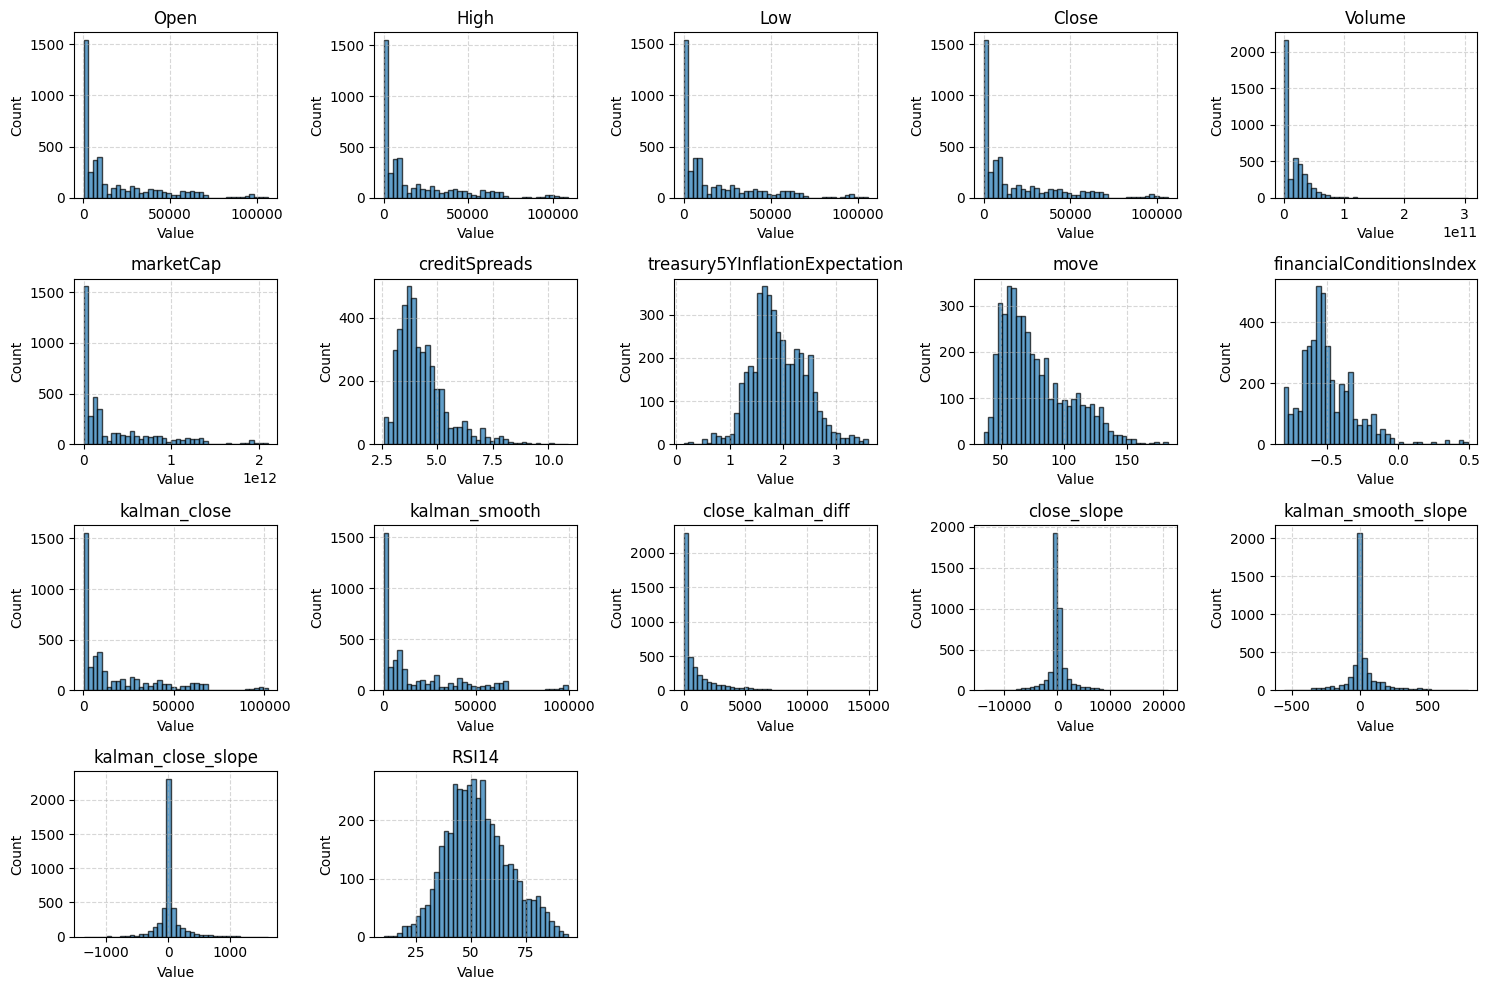

In [14]:
def calculate_atr(high, low, close, window=14):
    """
    Calculate the Average True Range (ATR).

    ATR is defined as the rolling average (window=14 by default) of the True Range.
    True Range (TR) is the maximum of:
      - (High - Low)
      - Absolute(High - previous Close)
      - Absolute(Low - previous Close)
    """
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=window, min_periods=window).mean()
    return atr

# Setup Kalman Filter (make sure data is loaded before setting initial_state_mean)
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=None,  # will be set after loading data
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

# Assume 'data' has already been loaded and merged with macro data.
df = data.copy()
df.dropna(inplace=True)

# Apply the Kalman filter on Close prices
kf.initial_state_mean = df['Close'].iloc[0]
state_means, state_covariances = kf.filter(df['Close'].values)
df['kalman_close'] = state_means.flatten()
smoothed_state_means, smoothed_state_covariances = kf.smooth(df['kalman_close'].values)
df['kalman_smooth'] = smoothed_state_means.flatten()
df['close_kalman_diff'] = np.abs(df['Close'] - df['kalman_smooth'])
df['close_slope'] = df['Close'].diff(periods=7)
df['kalman_smooth_slope'] = df['kalman_smooth'].diff(periods=1)
df['kalman_close_slope'] = df['kalman_close'].diff(periods=1)

# Compute technical indicators
df['RSI14'] = ta.rsi(df['Close'], length=14)


if asset != "bitcoin":
    # Load BTC dominance data
    btc_dom_data = pd.read_csv('/Users/valter.rebelo/MissionControl/data/micro/marketData/btc_dominance.csv', 
                              index_col=0,  # Use first column as index
                              parse_dates=True)  # Parse index as dates
    
    # Merge BTC dominance data with current asset data on index
    df = df.merge(btc_dom_data, 
                 left_index=True,
                 right_index=True,
                 how='left')
    
    # Rename the column to be more descriptive
    df.rename(columns={btc_dom_data.columns[0]: 'btc_dom'}, inplace=True)


plot_feature_distributions(df, feature_cols=df.columns, bins=40)

In [15]:
def split_data(df, train_size=0.8, embargo_size=0.01):
   
    # Calculate split indices
    n = len(df)
    train_end = int(n * train_size)
    embargo_end = train_end + int(n * embargo_size)
    
    # Split the data
    train = df[:train_end]
    embargo = df[train_end:embargo_end]
    test = df[embargo_end:]
    
    # Warn if embargo period is too short
    if len(embargo) < 5:
        warnings.warn("Embargo period is less than 5 data points")
    
    return train, embargo, test

In [16]:
df.reset_index(inplace=True)
train, embargo, test = split_data(df, train_size=0.8, embargo_size=0.01)

if asset == "bitcoin":
    train = train.loc[train['Date'] > '2016-01-01']


In [29]:
train.__len__()

2495

In [20]:
def process_features(df, scaler=None, is_training=False):
    """
    Process and scale features for the HMM model.
    """
    
    # Setup logging
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger('feature_processing')
    
    # Create a copy to avoid modifying the original
    processed_df = df.copy()
    logger.info(f"Processing features for {'training' if is_training else 'test/embargo'} set")
    logger.info(f"Initial shape: {processed_df.shape}")
    
    # Calculate volume returns first
    processed_df['volume_return'] = processed_df['Volume'].pct_change()
    
    # Now we can calculate quantiles and clip
    low_lim = processed_df['volume_return'].quantile(0.02)
    up_lim = processed_df['volume_return'].quantile(0.97)
    
    processed_df['volume_return'].clip(lower=low_lim, upper=up_lim, inplace=True)
    
    # Rest of the feature calculations
    processed_df['log'] = np.log(processed_df['Close'].replace(0, np.nan))
    processed_df['log_return'] = processed_df['log'].diff()
    processed_df['log_return_30'] = processed_df['log'].diff(periods=30)
    processed_df['log_return_7'] = processed_df['log'].diff(periods=7)

    if asset != "bitcoin":
        processed_df['btc_dom_return'] = processed_df['btc_dom'].pct_change(periods=1)

    # Process macro features if they exist
    for feature, log_name in [
        ('move', 'move_log'),
        ('treasury5YInflationExpectation', 'treasury5YInflationExpectation_log'),
        ('creditSpreads', 'creditSpreads_log')
    ]:
        if feature in processed_df.columns:
            logger.info(f"Processing {feature}")
            processed_df[log_name] = np.log(processed_df[feature].replace(0, np.nan))
            processed_df[f'{feature}_log_return'] = processed_df[log_name].diff()


    processed_df['lnrange'] = np.log((processed_df['High'] / processed_df['Low']).replace([np.inf, -np.inf], np.nan))
    
    processed_df['ln_atr'] = np.log(calculate_atr(
        processed_df['High'], 
        processed_df['Low'], 
        processed_df['Close'], 
        window=14).replace(0, np.nan))
    
    # Clean log returns before GARCH fitting
    clean_returns = processed_df['log_return'].copy()
    clean_returns = clean_returns.replace([np.inf, -np.inf], np.nan)
    clean_returns = clean_returns.dropna()
    
    # Fit GARCH model on clean returns
    logger.info("Fitting GARCH model")
    try:
        garch_model = arch_model(
            clean_returns,
            vol='GARCH', 
            p=1, 
            q=1, 
            mean='Zero', 
            dist='studentst'
        )
        garch_fit = garch_model.fit(disp='off')
        
        # Map GARCH volatilities back to original index
        vol_series = pd.Series(garch_fit.conditional_volatility, index=clean_returns.index)
        processed_df['garch_volatility'] = vol_series
    except Exception as e:
        logger.error(f"GARCH fitting failed: {str(e)}")
        processed_df['garch_volatility'] = processed_df['ln_atr']  # Use ATR as fallback
    
    # Define features to scale
    features_to_scale = [
        'log', 'log_return', 'lnrange',
        'RSI14', 'log_return_30', 'log_return_7', 'ln_atr',
        'kalman_close', 'kalman_smooth', 'kalman_smooth_slope', 
        'close_kalman_diff', 'volume_return', 'garch_volatility', 'marketCap'#, 'btc_dom','btc_dom_return'
    ]
    macro_features = [
        
        'creditSpreads_log_return', 'creditSpreads', 
        'creditSpreads_log', 'treasury5YInflationExpectation_log_return',
        'treasury5YInflationExpectation_log', 'treasury5YInflationExpectation', 
        'move_log_return', 'move_log', 'move'
    ]
    
    features_to_scale.extend([f for f in macro_features if f in processed_df.columns])
    
    logger.info(f"Scaling {len(features_to_scale)} features")
    
    # Handle any remaining NaN and infinite values before scaling
    for feature in features_to_scale:
        if feature in processed_df.columns:
            # Replace infinities with NaN
            processed_df[feature] = processed_df[feature].replace([np.inf, -np.inf], np.nan)
            # Forward fill NaN values
            processed_df[feature] = processed_df[feature].fillna(method='ffill')
            # Backward fill any remaining NaN values
            processed_df[feature] = processed_df[feature].fillna(method='bfill')
            # If still any NaN values, replace with 0
            remaining_nans = processed_df[feature].isna().sum()
            if remaining_nans > 0:
                logger.warning(f"Filling {remaining_nans} remaining NaNs in {feature} with 0")
                processed_df[feature] = processed_df[feature].fillna(0)

    # Scale features
    if is_training:
        logger.info("Fitting and transforming with StandardScaler")
        scaler = StandardScaler()
        processed_df[features_to_scale] = scaler.fit_transform(processed_df[features_to_scale])

    else:
        logger.info("Transforming with pre-fitted StandardScaler")
        if scaler is None:
            raise ValueError("Scaler must be provided when processing test data")
        processed_df[features_to_scale] = scaler.transform(processed_df[features_to_scale])

    processed_df.dropna(inplace=True)
    
    logger.info(f"Final shape: {processed_df.shape}")
    return processed_df, scaler

In [21]:

# Process training data
train_processed, scaler = process_features(train, is_training=True)

# Process test data using scaler from training
test_processed, _ = process_features(test, scaler=scaler, is_training=False)

# Process embargo data using same scaler
embargo_processed, _ = process_features(embargo, scaler=scaler, is_training=False)

INFO:feature_processing:Processing features for training set
INFO:feature_processing:Initial shape: (2495, 18)
INFO:feature_processing:Processing move
INFO:feature_processing:Processing treasury5YInflationExpectation
INFO:feature_processing:Processing creditSpreads
INFO:feature_processing:Fitting GARCH model
INFO:feature_processing:Scaling 23 features
INFO:feature_processing:Fitting and transforming with StandardScaler
INFO:feature_processing:Final shape: (2495, 32)
INFO:feature_processing:Processing features for test/embargo set
INFO:feature_processing:Initial shape: (826, 18)
INFO:feature_processing:Processing move
INFO:feature_processing:Processing treasury5YInflationExpectation
INFO:feature_processing:Processing creditSpreads
INFO:feature_processing:Fitting GARCH model
INFO:feature_processing:Scaling 23 features
INFO:feature_processing:Transforming with pre-fitted StandardScaler
INFO:feature_processing:Final shape: (826, 32)
INFO:feature_processing:Processing features for test/emba

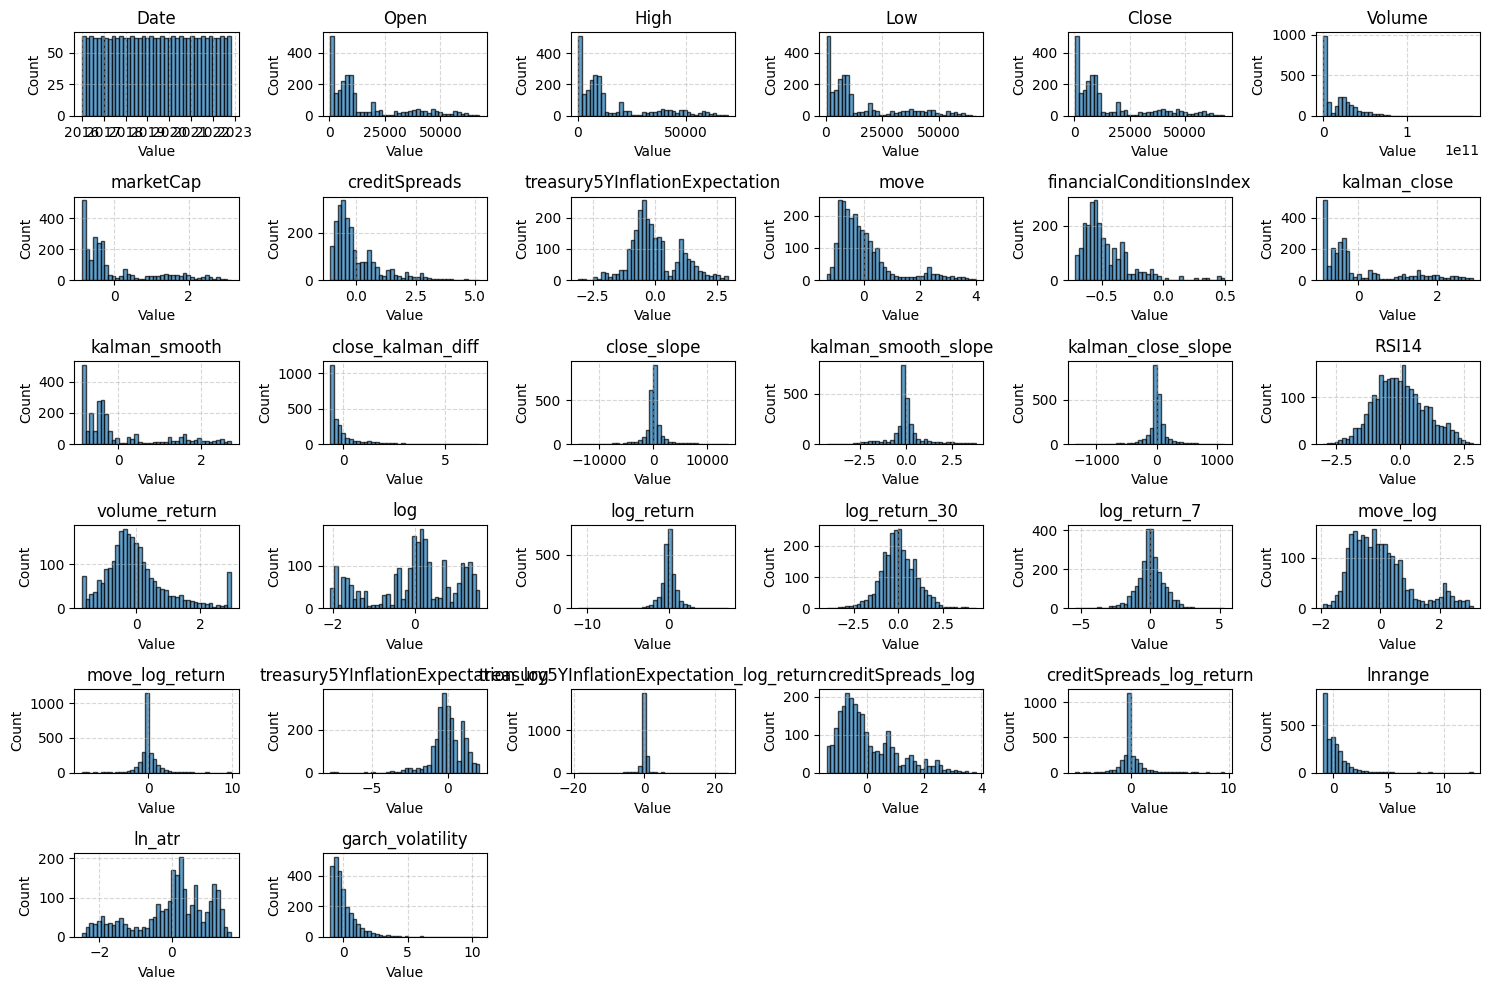

In [22]:
plot_feature_distributions(train_processed, feature_cols=train_processed.columns, bins=40)

## HMM Model

In [23]:

# Set random seeds for reproducibility
np.random.seed(4214609)  # for numpy operations
random.seed(4214609)     # for Python's random module

# ln vor btc has bad results du to dirty data at the beginning, shallow liquidity

features_btc = ['Date', 'kalman_smooth_slope'] 

features_alts = ['Date', 'garch_volatility', 'btc_dom_return', 'RSI14']


#set features
f_train = train_processed[features_btc if asset == "bitcoin" else features_alts].set_index('Date')

f_test = test_processed[features_btc if asset == "bitcoin" else features_alts].set_index('Date')

hmm = GaussianHMM(n_components=2, 
                  covariance_type="full", n_iter=100000000, verbose=False, init_params='mc')


 
hmm.fit(f_train)

#predict hidden states on test set
hidden_states = hmm.predict(f_test)


In [448]:
''' Mean adjusted states
def generate_hmm_states(hmm, test, f_test, mode='long-only'):

    if mode == 'long-only':

        #state 0 mean return and var
        s0_mean_ret = hmm.means_[0]
        s0_mean_ret = s0_mean_ret[0]
        s0_var_ret = np.diag(hmm.covars_[0])
        s0_var_ret = s0_var_ret[0]
        
        #state 1 mean return and var
        s1_mean_ret = hmm.means_[1]
        s1_mean_ret = s1_mean_ret[0]
        s1_var_ret = np.diag(hmm.covars_[1])
        s1_var_ret = s1_var_ret[0]
        
        #state 2 mean return and var
        s2_mean_ret = hmm.means_[2]
        s2_mean_ret = s2_mean_ret[0]
        s2_var_ret = np.diag(hmm.covars_[2])
        s2_var_ret = s2_var_ret[0]
        
        #find favoured state (return wise, no account for var)
        if s0_mean_ret > s1_mean_ret and s0_mean_ret > s2_mean_ret:
            fav_state = 0    
        if s1_mean_ret > s0_mean_ret and s1_mean_ret > s2_mean_ret:
            fav_state = 1
        if s2_mean_ret > s0_mean_ret and s2_mean_ret > s1_mean_ret:
            fav_state = 2
        
        #create time series of states
        hmm_state_series = test.copy()
        
        hmm_state_series['hidden_state'] = hidden_states
        
        hmm_state_series.loc[hmm_state_series['hidden_state'] 
                            == fav_state,'state'] = 'Long'
        
        hmm_state_series.loc[hmm_state_series['hidden_state'] 
                            != fav_state,'state'] = 'Flat'
        
        hmm_state_series['return'] = hmm_state_series['log'].pct_change()
                                                                    
        #create df of state certainty
        p_of_states = pd.DataFrame(hmm.predict_proba(f_test))
        
        #create df of probability curr state is favourable (mean_ret > 0)
        fav = p_of_states[fav_state]
        p_of_states_fav_unfav = pd.DataFrame(fav)
        
        unfav = []
        for i in fav:
            j = 1-i
            unfav.append(j)
        
        p_of_states_fav_unfav.insert(1,'unfav',unfav)

    if mode == 'long-short':
        
        # Extract the first dimension's mean (i.e., mean log_return) for each state
        s0_mean_ret = hmm.means_[0][0]  
        s1_mean_ret = hmm.means_[1][0]
        s2_mean_ret = hmm.means_[2][0]

        state_means = [s0_mean_ret, s1_mean_ret, s2_mean_ret]
        print("State means:", state_means)  # Debug print

        # Identify which index (0,1,2) has the highest and lowest returns
        max_state = np.argmax(state_means)
        min_state = np.argmin(state_means)
        print(f"Max state: {max_state}, Min state: {min_state}")  # Debug print

        hmm_state_series = test.copy()

        # Drop unneeded columns
        columns_to_keep = ['log']  
        hmm_state_series = hmm_state_series[columns_to_keep]

        # Add state information
        hmm_state_series['hidden_state'] = hidden_states

        # Default everything to "Flat"
        hmm_state_series['state'] = 'Flat'

        # Assign Long/Short states
        hmm_state_series.loc[hmm_state_series['hidden_state'] == max_state, 'state'] = 'Long'
        hmm_state_series.loc[hmm_state_series['hidden_state'] == min_state, 'state'] = 'Short'

        # Add returns
        hmm_state_series['return'] = hmm_state_series['log'].pct_change()

        # Get state probabilities with proper index and column names
        p_of_states = pd.DataFrame(
            hmm.predict_proba(f_test),
            index=f_test.index,
            columns=[f'state_{i}' for i in range(3)]  # Create column names
        )

        # Create fav/unfav probabilities
        p_of_states_fav_unfav = pd.DataFrame(index=f_test.index)
        p_of_states_fav_unfav['fav'] = p_of_states[f'state_{max_state}']  # Use string column name
        p_of_states_fav_unfav['unfav'] = 1 - p_of_states_fav_unfav['fav']

    return hmm_state_series, p_of_states_fav_unfav
'''

' Mean adjusted states\ndef generate_hmm_states(hmm, test, f_test, mode=\'long-only\'):\n\n    if mode == \'long-only\':\n\n        #state 0 mean return and var\n        s0_mean_ret = hmm.means_[0]\n        s0_mean_ret = s0_mean_ret[0]\n        s0_var_ret = np.diag(hmm.covars_[0])\n        s0_var_ret = s0_var_ret[0]\n        \n        #state 1 mean return and var\n        s1_mean_ret = hmm.means_[1]\n        s1_mean_ret = s1_mean_ret[0]\n        s1_var_ret = np.diag(hmm.covars_[1])\n        s1_var_ret = s1_var_ret[0]\n        \n        #state 2 mean return and var\n        s2_mean_ret = hmm.means_[2]\n        s2_mean_ret = s2_mean_ret[0]\n        s2_var_ret = np.diag(hmm.covars_[2])\n        s2_var_ret = s2_var_ret[0]\n        \n        #find favoured state (return wise, no account for var)\n        if s0_mean_ret > s1_mean_ret and s0_mean_ret > s2_mean_ret:\n            fav_state = 0    \n        if s1_mean_ret > s0_mean_ret and s1_mean_ret > s2_mean_ret:\n            fav_state = 1\n 

## Sharpe adjusted states

In [30]:
def generate_hmm_states(hmm, test, f_test, mode='long-only', aggressor=False):
    # Calculate Sharpe ratios for all states (used in both modes)
    s0_mean_ret = hmm.means_[0][0]
    s0_var_ret = np.diag(hmm.covars_[0])[0]
    
    s1_mean_ret = hmm.means_[1][0]
    s1_var_ret = np.diag(hmm.covars_[1])[0]
    
    #s2_mean_ret = hmm.means_[2][0]
    #s2_var_ret = np.diag(hmm.covars_[2])[0]
    
    # Calculate Sharpe-like ratio for each state
    s0_sharpe = s0_mean_ret / np.sqrt(s0_var_ret) if s0_var_ret > 0 else -np.inf
    s1_sharpe = s1_mean_ret / np.sqrt(s1_var_ret) if s1_var_ret > 0 else -np.inf
    #s2_sharpe = s2_mean_ret / np.sqrt(s2_var_ret) if s2_var_ret > 0 else -np.inf
    
    state_shares = [s0_sharpe, s1_sharpe]
    print(f'State Sharpe Ratios: {state_shares}')

    if mode == 'long-only':
        fav_state = np.argmax(state_shares)
        
        # Create time series of states
        hmm_state_series = test.copy()
        hmm_state_series['hidden_state'] = hidden_states
        
        # Assign trading signals based on favored state (risk-adjusted)
        hmm_state_series.loc[hmm_state_series['hidden_state'] == fav_state, 'state'] = 'Long'
        hmm_state_series.loc[hmm_state_series['hidden_state'] != fav_state, 'state'] = 'Flat'
        
        # Add returns
        hmm_state_series['return'] = hmm_state_series['log'].diff()
                                                                    
        # Create df of state certainty
        p_of_states = pd.DataFrame(hmm.predict_proba(f_test))
        
        # Create df of probability current state is favorable (risk-adjusted)
        fav = p_of_states[fav_state]
        p_of_states_fav_unfav = pd.DataFrame(fav)
        unfav = [1 - x for x in fav]
        p_of_states_fav_unfav.insert(1, 'unfav', unfav)
    
    if mode == 'long-short':
        if aggressor:
            # Original behavior: Short any negative Sharpe state
            state_signals = ['Long' if sharpe >= 0 else 'Short' for sharpe in state_shares]

        else:
            # Conservative behavior: Short only the most negative state, Flat for other negative states
            min_sharpe_idx = np.argmin(state_shares)
            state_signals = []
            for i, sharpe in enumerate(state_shares):
                if sharpe >= 0:
                    state_signals.append('Long')
                elif i == min_sharpe_idx:
                    state_signals.append('Short')
                else:
                    state_signals.append('Flat')
        
        print(f'State Signals based on Sharpe: {state_signals}')
        
        # Create time series of states
        hmm_state_series = test.copy()
        hmm_state_series['hidden_state'] = hidden_states
        
        # Map each hidden state to its corresponding trading signal from state_signals
        hmm_state_series['state'] = hmm_state_series['hidden_state'].map(lambda x: state_signals[x])
        
        # Add returns
        hmm_state_series['return'] = hmm_state_series['log'].diff()
        
        # Get state probabilities with proper index and column names
        p_of_states = pd.DataFrame(
            hmm.predict_proba(f_test),
            index=f_test.index,
            columns=[f'state_{i}' for i in range(2)]
        )
        
        # Define 'fav' as the probability of being in a state with a Long signal
        long_states = [f'state_{i}' for i, signal in enumerate(state_signals) if signal == 'Long']
        if long_states:
            p_long = p_of_states[long_states].sum(axis=1)
        else:
            p_long = pd.Series(0, index=f_test.index)
        
        # Create a DataFrame with prob. of favorable (Long) and unfavorable (Short) states
        p_of_states_fav_unfav = pd.DataFrame(index=f_test.index)
        p_of_states_fav_unfav['fav'] = p_long
        p_of_states_fav_unfav['unfav'] = 1 - p_long
    
    return hmm_state_series, p_of_states_fav_unfav

State Sharpe Ratios: [-0.34767006640178283, 2.382810998097217]
State Signals based on Sharpe: ['Short', 'Long']
State Sharpe Ratios: [-0.34767006640178283, 2.382810998097217]


array([[<Axes: title={'center': '1'}>, <Axes: title={'center': 'unfav'}>]],
      dtype=object)

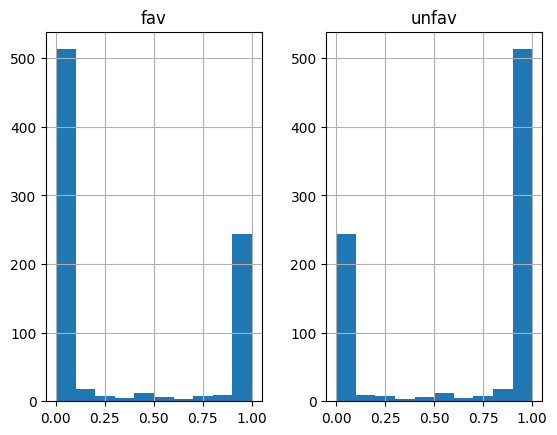

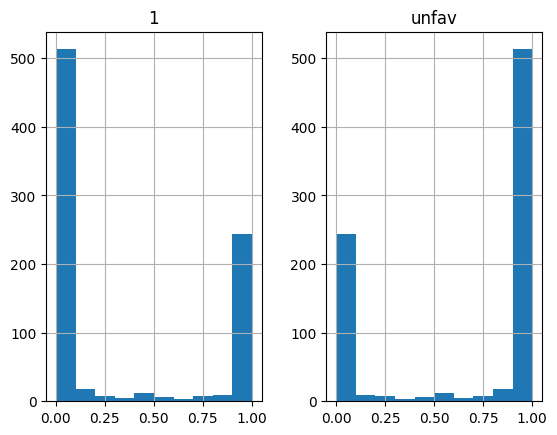

In [31]:
hmm_state_series_long_short, p_of_states_fav_unfav_long_short = generate_hmm_states(hmm, test_processed, f_test, mode='long-short')
hmm_state_series_long_only, p_of_states_fav_unfav_long_only = generate_hmm_states(hmm, test_processed, f_test, mode='long-only')
p_of_states_fav_unfav_long_short.hist()
p_of_states_fav_unfav_long_only.hist()

## Generate trading signals

In [26]:
def transact_at_open(test, hmm_state_series, p_of_states_fav_unfav):
    """
    Creates trading signals based on HMM states and calculates strategy returns.
    
    Parameters:
    -----------
    test : pd.DataFrame
        Must include columns: 'Open'
    hmm_state_series : pd.DataFrame
        Must include columns: 'hidden_state', 'state' where state is one of:
        'Long' (1), 'Short' (-1), or 'Flat' (0)
    p_of_states_fav_unfav : pd.DataFrame
        Contains state probabilities (not used in signal generation but kept for analysis)
    
    Returns:
    --------
    pd.DataFrame
        Copy of test DataFrame with additional columns:
        - 'raw_position'      : position from HMM state (-1, 0, or 1)
        - 'signal'           : trading signal (raw_position shifted by 1)
        - 'next_open'        : next day's open price
        - 'open_return'      : return from today's open to next day's open
        - 'strategy_return'  : product of signal and open_return
        - 'trade'           : indicator (1/0) if trade occurred
        - 'cum_strategy_return' and 'cum_buy_hold_return': cumulative returns
    """

    
    # Start with a copy of the test DataFrame
    df = test.copy()
    
    # Ensure index alignment
    p_of_states_fav_unfav.index = test.index
    
    # Join the HMM state information
    df = df.join(hmm_state_series[['hidden_state', 'state']])
    df = df.join(p_of_states_fav_unfav['unfav'])
    
    # Convert state to position (-1, 0, 1)
    df['raw_position'] = df['state'].map({'Long': 1.0, 'Short': -1.0, 'Flat': 0.0})
    
    # Shift the raw position once to simulate trading at the next day's open
    df['signal'] = df['raw_position'].shift(1)
    
    # Calculate returns
    df['next_open'] = df['Open'].shift(-1)
    df['open_return'] = (df['next_open'] / df['Open']) - 1
    df['open_return'] = df['open_return'].fillna(0)
    df['strategy_return'] = df['signal'] * df['open_return']
    
    # Mark trades
    df['trade'] = (df['signal'] != df['signal'].shift(1)).astype(int)
    
    # Calculate cumulative returns
    df['cum_strategy_return'] = (1 + df['strategy_return']).cumprod() - 1
    df['cum_buy_hold_return'] = (1 + df['open_return']).cumprod() - 1
    
    df['state'].hist()

    return df

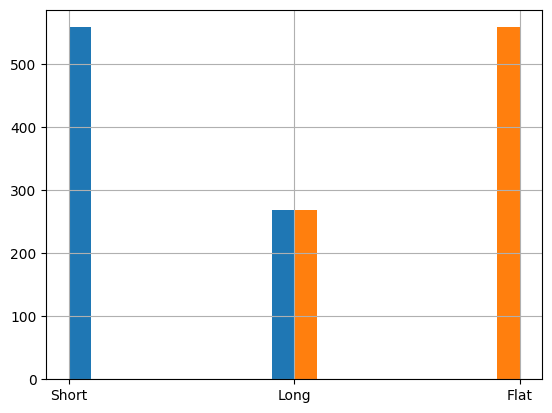

In [27]:
long_short = transact_at_open(test_processed, hmm_state_series_long_short, p_of_states_fav_unfav_long_short)
long_only = transact_at_open(test_processed, hmm_state_series_long_only, p_of_states_fav_unfav_long_only)


### Plot strategy results

In [28]:
def plot_hmm_results(df):
    """
    Given a DataFrame (such as that returned by transact_at_open()) that includes:
      - Date (as a column)
      - 'hidden_state': the raw state from the HMM (e.g. 0, 1, or 2)
      - 'cum_buy_hold_return': cumulative return from buying and holding the asset
      - 'cum_strategy_return': cumulative return from the HMM-based strategy
      - 'unfav': the probability that the state is unfavored
    this function produces a two-panel interactive Plotly plot and backtest metrics.
    """
    
    # Ensure Date is datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    # Calculate backtest metrics
    def calculate_metrics(returns, cum_returns, is_strategy=True, df=None):
        total_return = cum_returns.iloc[-1]
        
        # Annualized return (assuming daily data)
        days = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
        ann_return = ((1 + total_return) ** (365/days)) - 1
        
        if is_strategy:
            # Count state changes (excluding changes to/from flat)
            state_changes = df['raw_position'].diff().fillna(0)
            trades = (state_changes != 0).sum()
            
            # Calculate win rate based on daily returns during active positions
            active_returns = returns[df['raw_position'] != 0]
            win_rate = (active_returns > 0).sum() / len(active_returns) if len(active_returns) > 0 else 0
        else:
            # Buy & hold has no trades
            trades = 0
            win_rate = 0
        
        # Drawdown calculations
        wealth_index = 1 + cum_returns
        previous_peaks = wealth_index.expanding(min_periods=1).max()
        drawdowns = (wealth_index - previous_peaks) / previous_peaks
        max_drawdown = drawdowns.min()
        
        # Sharpe ratio (assuming daily data)
        risk_free_rate = 0.02  # 2% annual risk-free rate
        daily_rf = (1 + risk_free_rate) ** (1/365) - 1
        excess_returns = returns - daily_rf
        sharpe = np.sqrt(365) * (excess_returns.mean() / returns.std())
        
        return {
            'Total Return': f'{total_return:.2%}',
            'Annualized Return': f'{ann_return:.2%}',
            'Number of Trades': trades,
            'Max Drawdown': f'{max_drawdown:.2%}',
            'Sharpe Ratio': f'{sharpe:.2f}',
            'Win Rate': f'{win_rate:.2%}'
        }
    
    # Calculate metrics for both strategy and buy & hold
    strategy_metrics = calculate_metrics(df['strategy_return'], 
                                      df['cum_strategy_return'], 
                                      is_strategy=True, 
                                      df=df)
    
    bh_metrics = calculate_metrics(df['open_return'], 
                                 df['cum_buy_hold_return'], 
                                 is_strategy=False,
                                 df=df)  # Added df parameter here

    # Create metrics table
    metrics_table = pd.DataFrame({
        'Strategy': strategy_metrics,
        'Buy & Hold': bh_metrics
    }).round(4)
    
    # Create figure with three rows (added space for table)
    fig = make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        row_heights=[0.5, 0.2, 0.3],
        specs=[[{"type": "scatter"}],
               [{"type": "table"}],
               [{"type": "scatter"}]]
    )

    # Top Panel: Returns
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_buy_hold_return'],
            mode='markers',
            name='Buy & Hold',
            marker=dict(
                size=4,
                color=df['hidden_state'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title='Hidden State')
            )
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_strategy_return'],
            mode='lines',
            name='HMM Strategy',
            line=dict(color='red', width=2)
        ),
        row=1, col=1
    )
    
    # Middle Panel: Metrics Table
    fig.add_trace(
        go.Table(
            header=dict(
                values=['Metric', 'Strategy', 'Buy & Hold'],
                font=dict(size=12),
                align="left"
            ),
            cells=dict(
                values=[metrics_table.index, 
                        metrics_table['Strategy'],
                        metrics_table['Buy & Hold']],
                font=dict(size=11),
                align="left"
            )
        ),
        row=2, col=1
    )
    
    # Bottom Panel: Unfavored Probability
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['unfav'],
            mode='lines',
            name='Unfavored Probability',
            line=dict(color='black', width=2)
        ),
        row=3, col=1
    )
    
    # Update layout
    fig.update_layout(
        title='HMM-Regime Based Strategy Analysis',
        template='plotly_white',
        height=1000,  # Increased height to accommodate table
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Update y-axes labels
    fig.update_yaxes(title_text="Cumulative Return", row=1, col=1)
    fig.update_yaxes(title_text="Unfavored Probability", row=3, col=1)
    
    # Update x-axis label
    fig.update_xaxes(title_text="Date", row=3, col=1)
    
    # Show the plot
    fig.show()

State Transition Probabilities:
          State 0   State 1
State 0  0.998191  0.001809
State 1  0.014415  0.985585


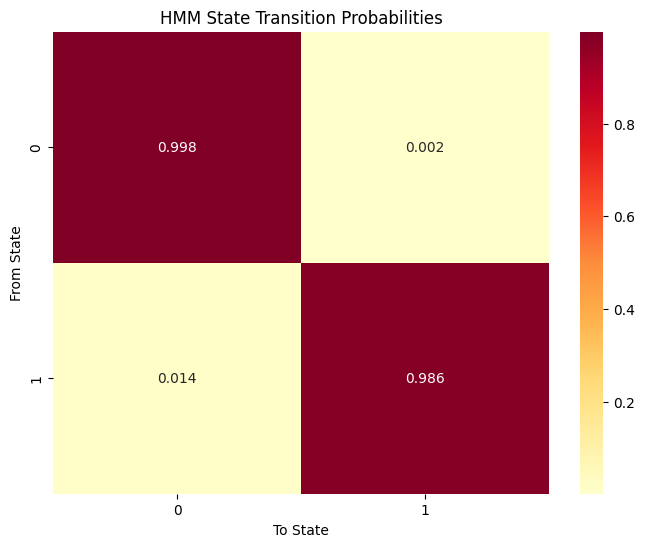

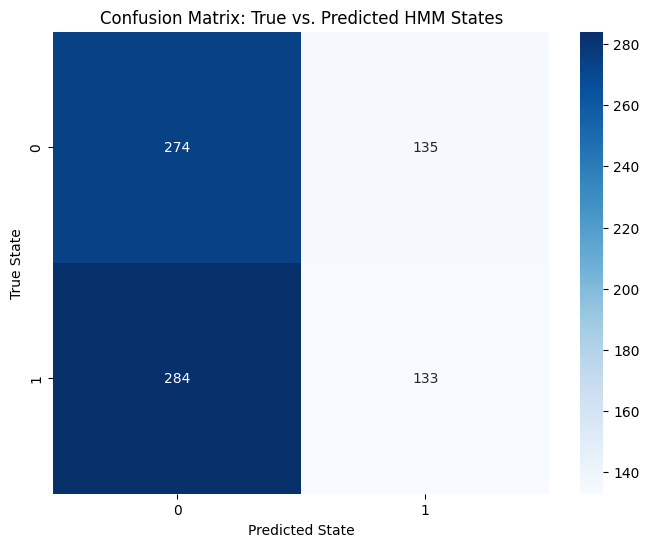

Confusion Matrix:
[[274 135]
 [284 133]]


In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'hmm' is your fitted GaussianHMM model
transmat = hmm.transmat_  # This is the transition matrix (n_states x n_states)

# Print the transition matrix
print("State Transition Probabilities:")
print(pd.DataFrame(transmat, 
                   index=[f'State {i}' for i in range(hmm.n_components)],
                   columns=[f'State {i}' for i in range(hmm.n_components)]))

# Visualize the transition matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(transmat, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title('HMM State Transition Probabilities')
plt.xlabel('To State')
plt.ylabel('From State')
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have 'hidden_states' from hmm.predict(f_test) for the test set
predicted_states = hidden_states  # Your HMM predictions

# Hypothetical true states (you’d need to define these based on your data or domain)
# For example, let’s simulate true states for demonstration (replace with real data)
true_states = np.random.randint(0, 2, size=len(predicted_states))  # Random for illustration

# Compute confusion matrix
cm = confusion_matrix(true_states, predicted_states)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: True vs. Predicted HMM States')
plt.xlabel('Predicted State')
plt.ylabel('True State')
plt.show()

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)


In [32]:
plot_hmm_results(long_only)
plot_hmm_results(long_short)

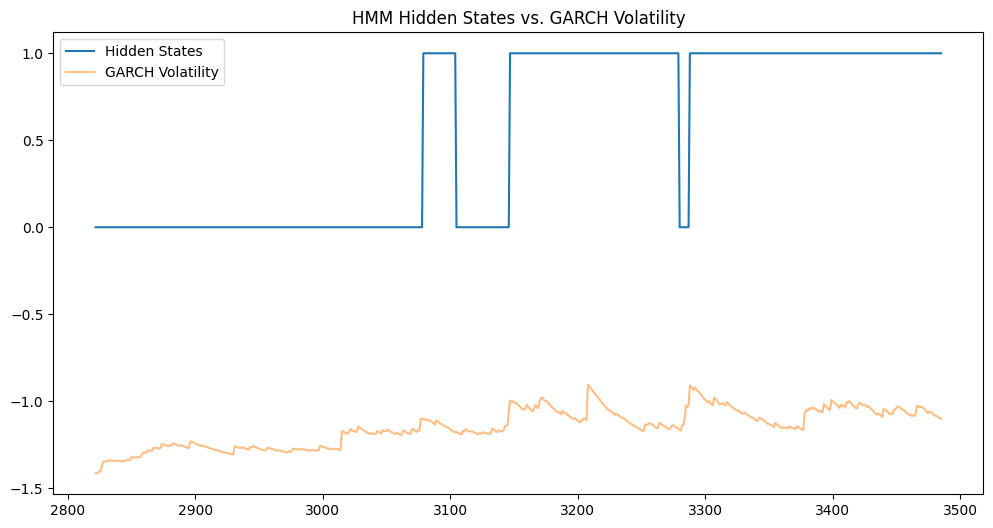

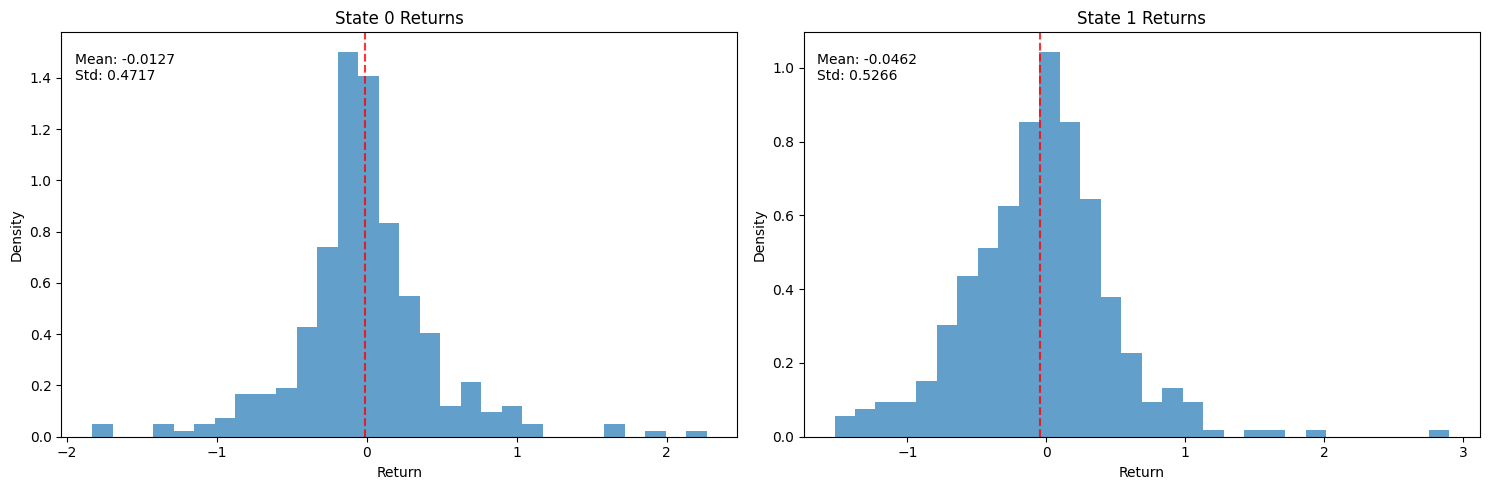

In [456]:
# Add hidden states to your test DataFrame
test_processed['hidden_states'] = hidden_states

# Plot hidden states and GARCH volatility
plt.figure(figsize=(12, 6))
plt.plot(test_processed.index, test_processed['hidden_states'], label='Hidden States')
plt.plot(test_processed.index, test_processed['garch_volatility'], label='GARCH Volatility', alpha=0.5)
plt.legend()
plt.title('HMM Hidden States vs. GARCH Volatility')
plt.show()

# Create a figure with subplots for each state
plt.figure(figsize=(15, 5))

# Get unique states
unique_states = test_processed['hidden_states'].unique()

# Create a subplot for each state
for i, state in enumerate(sorted(unique_states)):
    plt.subplot(1, len(unique_states), i+1)
    
    # Get returns for this state
    state_returns = test_processed.loc[test_processed['hidden_states'] == state, 'log_return']
    
    # Plot histogram
    plt.hist(state_returns, bins=30, alpha=0.7, density=True)
    plt.title(f'State {state} Returns')
    plt.xlabel('Return')
    plt.ylabel('Density')
    
    # Add mean and std to the plot
    mean_ret = state_returns.mean()
    std_ret = state_returns.std()
    plt.axvline(mean_ret, color='r', linestyle='dashed', alpha=0.8)
    plt.text(0.02, 0.95, f'Mean: {mean_ret:.4f}\nStd: {std_ret:.4f}', 
             transform=plt.gca().transAxes, 
             verticalalignment='top')

plt.tight_layout()
plt.show()